# Massey ranking

Description: Construct a Massey ranking of data.
  

### Set parameters

gameFilename - game data file, presumed to be in the format from 
the Massey rating data server, which can be found at 
http://www.masseyratings.com/. 

teamFilename - team data file

k - number of teams to print in the final ranking - set to 0 to get all teams

In [5]:
gameFilename = '24games.txt'
teamFilename = '24teams.txt'
k = 20

### Load the team names into an array

In [8]:
import pandas as pd

teamNames = pd.read_csv(teamFilename, header = None)
numTeams = len(teamNames)

### Load the games

In [11]:
# columns of games are:
#	column 0 = days since 1/1/0000
#	column 1 = date in YYYYMMDD format
#	column 2 = team1 index
#	column 3 = team1 homefield (1 = home, -1 = away, 0 = neutral)
#	column 4 = team1 score
#	column 5 = team2 index
#	column 6 = team2 homefield (1 = home, -1 = away, 0 = neutral)
#	column 7 = team2 score
games = pd.read_csv(gameFilename, header = None)
numGames = len(games)

### Create the Massey linear system

In [14]:
import numpy as np

masseyMatrix = np.zeros((numTeams,numTeams))
b = np.zeros(numTeams)

for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 # subtracting 1 since python indexes at 0
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 # subtracting 1 since python indexes at 0
    team2Score = games.loc[i, 7]
    
    masseyMatrix[team1ID, team2ID] -= 1
    masseyMatrix[team2ID, team1ID] -= 1

    masseyMatrix[team1ID, team1ID] += 1
    masseyMatrix[team2ID, team2ID] += 1
    
    pointDifferential = abs(team1Score - team2Score)
    
    if team1Score > team2Score:
        b[team1ID] += pointDifferential
        b[team2ID] -= pointDifferential
    elif team1Score < team2Score:
        b[team1ID] -= pointDifferential
        b[team2ID] += pointDifferential
        
# replace last row with ones and 0 on RHS
masseyMatrix[-1,:] = np.ones((1,numTeams))
b[-1] = 0

### Calculate linear system

In [39]:
r = np.linalg.solve(masseyMatrix,b)
iSort = np.argsort(-r)
r

array([-2.17985125,  1.96957404,  2.59026369, -1.28329953,  2.01555105,
        2.07302231, -0.83502366,  1.08451657,  2.70520622,  2.75118323,
        2.59026369,  0.40635565,  0.60175794,  2.40635565,  2.75118323,
        2.10980392,  1.97647059,  1.84313725,  1.77647059,  1.57647059,
        1.50980392,  1.30980392,  1.30980392,  1.24313725,  1.04313725,
        0.97647059,  0.90980392,  0.84313725,  0.70980392,  0.70980392,
        0.70980392,  0.70980392,  0.57647059,  0.57647059,  0.64313725,
        0.64313725,  0.57647059,  0.50980392,  0.44313725,  0.44313725,
        0.37647059,  0.30980392,  0.17647059,  0.17647059,  0.17647059,
        0.10980392,  0.10980392,  0.04313725,  0.04313725,  0.04313725,
       -0.09019608, -0.09019608, -0.02352941, -0.15686275, -0.22352941,
       -0.22352941, -0.29019608, -0.35686275, -0.35686275, -0.35686275,
       -0.55686275, -0.69019608, -0.62352941, -0.62352941, -0.75686275,
       -0.69019608, -0.69019608, -0.75686275, -0.82352941, -0.89

### Print the ranking of the teams

In [20]:
print('\n\n************** MASSEY Rating Method **************\n')
print('===========================')
print('Rank   Rating    Team   ')
print('===========================')
if k==0:
    numberTeamToPrint = numTeams
else:
    numberTeamToPrint = k

for i in range(numberTeamToPrint):
    print(f'{i+1:4d}   {r[iSort[i]]:.5f}  {teamNames.loc[iSort[i],1]}')

print('')   # extra carriage return



************** MASSEY Rating Method **************

Rank   Rating    Team   
   1   2.75118   10
   2   2.75118   15
   3   2.70521   9
   4   2.59026   3
   5   2.59026   11
   6   2.40636   14
   7   2.10980   Сахипов Амир
   8   2.07302   6
   9   2.01555   5
  10   1.97647   Шарел Марғұлан
  11   1.96957   2
  12   1.84314   Юркевич Мирон
  13   1.77647   Даутов Жан
  14   1.57647   Аманжолов Амирлан
  15   1.50980   Мурат Тимур
  16   1.30980   Маратұлы Әлинұр
  17   1.30980   Роговский Владимир
  18   1.24314   Таңсықбай Абзал
  19   1.08452   8
  20   1.04314   Нәрік Арсен



In [22]:
index = np.where(iSort == 0)[0][0]
print(index)
ProblemFile = open("Problem ranking Massey", "w")
for i in range(15):
    index = np.where(iSort == i)[0][0]
    ProblemFile.write('%3i,%3i, %f\n' %(i+1,index+1, r[iSort[index]]))
ProblemFile.close()

101


In [24]:
index = np.where(iSort == 9)[0][0]
print(index)
r[iSort[index]]

0


2.7511832319134557

### Calculate predictability of method

In [27]:
numberCorrectPredictions = 0
for i in range(numGames):
    team1ID = games.loc[i, 2] - 1 
    team1Score = games.loc[i, 4]
    team2ID = games.loc[i, 5] - 1 
    team2Score = games.loc[i, 7]
    
    if team1Score > team2Score and r[team1ID] > r[team2ID]:
        numberCorrectPredictions += 1
    elif team2Score > team1Score and r[team2ID] > r[team1ID]:
        numberCorrectPredictions += 1
    elif team1Score == team2Score and r[team1ID] == r[team2ID]:
        numberCorrectPredictions += 1

print(f'Predictability: {numberCorrectPredictions/numGames*100:.2f}%') 


Predictability: 89.35%


In [29]:
points=pd.read_csv('24points.txt', header = None)
for i in range(15):
    Psum=points.iloc[:,i+1].sum()
    print(Psum)

502
83
18
414
76
67
366
170
7
2
18
238
215
36
2


# Looking at students

In [127]:
#teamNames - all teams. column 0 - index, column 1 - player. rows 0-14 - problems
studNames=teamNames.iloc[15:,1] #array with students only(ranked by points)
#r - ratings by indexes
studRating=r[15:]#rating of students
pointFilename='24points.txt' #points
points=pd.read_csv(pointFilename, header=None)
studPoints=points.iloc[:,16]
studNames=studNames.reset_index(drop=True)

## Rank comparision 

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau

# ---- 1. Your Data as Arrays ----
names = studNames  # Add all 87 names here
pointSum = studPoints                  # Replace with actual point scores
methodA = pd.Series(r[15:]).reset_index(drop=True)      # Replace with your Method A ratings




In [131]:
# ---- 2. Create DataFrame ----
data = pd.DataFrame({
    'name': names,
    'pointSum': pointSum,
    'methodA': methodA
})

data

,name,pointSum,methodA
0,Сахипов Амир,66,2.109804
1,Шарел Марғұлан,64,1.976471
2,Юркевич Мирон,61,1.843137
3,Даутов Жан,60,1.776471
4,Аманжолов Амирлан,57,1.576471
...,...,...,...
82,Устинов Александр,3,-1.490196
83,Тұрсынбай Ақнұр,3,-1.490196
84,Мурат Жанторе,1,-1.623529
85,Усманов Анвар,1,-1.623529


=== Correlation Between Olympiad Ranking and Method A ===
Spearman Rank Correlation: 0.999
Kendall's Tau: 0.985



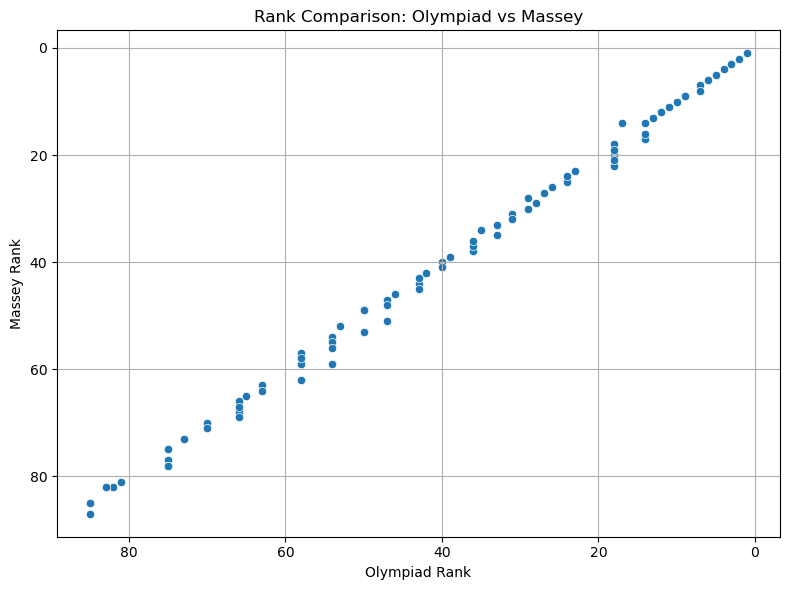

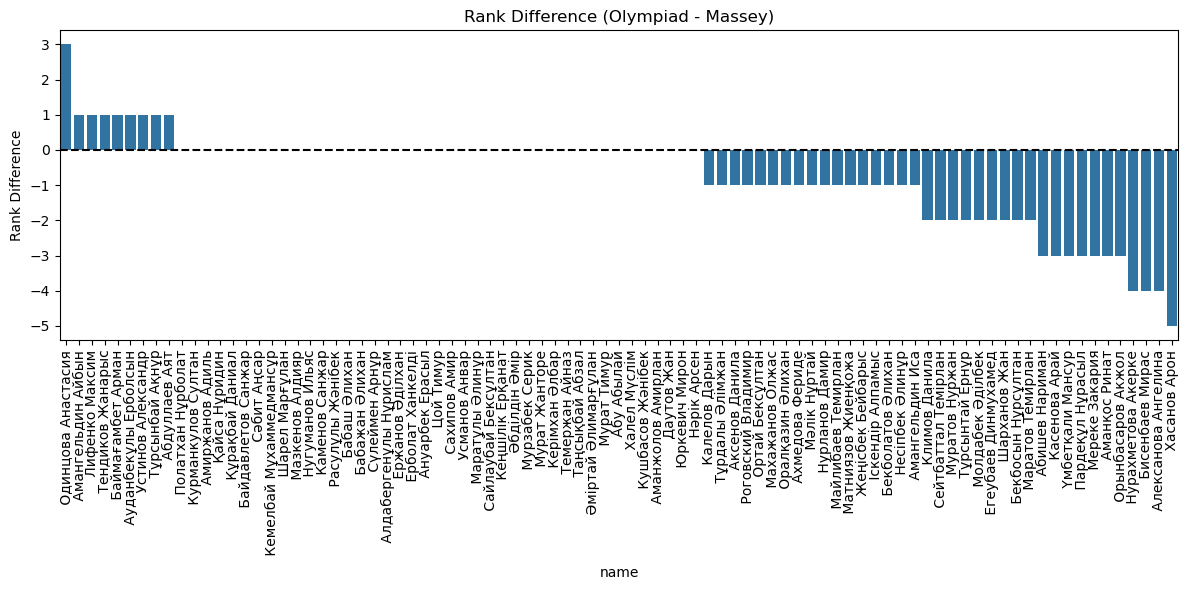

In [164]:

# ---- 3. Compute Rankings ----
data['rank_score'] = data['pointSum'].rank(ascending=False, method='min').astype(int)
data['rank_methodA'] = data['methodA'].rank(ascending=False, method='min').astype(int)
data['rank_diff'] = data['rank_score'] - data['rank_methodA']

# ---- 4. Correlation Analysis ----
spearman_corr, _ = spearmanr(data['rank_score'], data['rank_methodA'])
kendall_corr, _ = kendalltau(data['rank_score'], data['rank_methodA'])

print("=== Correlation Between Olympiad Ranking and Method A ===")
print(f"Spearman Rank Correlation: {spearman_corr:.3f}")
print(f"Kendall's Tau: {kendall_corr:.3f}\n")

# ---- 5. Scatter Plot ----
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rank_score', y='rank_methodA', data=data)
plt.title("Rank Comparison: Olympiad vs Massey")
plt.xlabel("Olympiad Rank")
plt.ylabel("Massey Rank")
plt.grid(True)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---- 6. Rank Difference Bar Plot ----
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='rank_diff', data=data.sort_values('rank_diff', ascending=False))
plt.xticks(rotation=90)
plt.title("Rank Difference (Olympiad - Massey)")
plt.ylabel("Rank Difference")
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


## 1. Plot Relationship Between pointSum and methodA (Correlation Visualization)

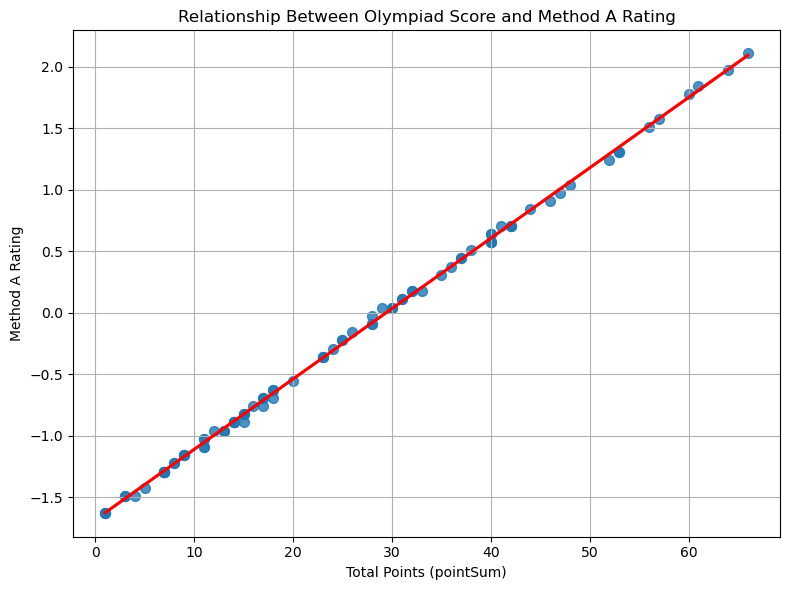

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(x='pointSum', y='methodA', data=data, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title("Relationship Between Olympiad Score and Method A Rating")
plt.xlabel("Total Points (pointSum)")
plt.ylabel("Method A Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

## Detect and Plot Outliers (by Residuals or Distance from Fit)


In [137]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Reshape inputs for sklearn
X = data['pointSum'].values.reshape(-1, 1)
y = data['methodA'].values

# Fit linear model
model = LinearRegression()
model.fit(X, y)
predicted = model.predict(X)

# Calculate residuals
data['residual'] = y - predicted

# Define outliers: residuals greater than 2 standard deviations
threshold = 2 * np.std(data['residual'])
outliers = data[abs(data['residual']) > threshold]

print(f"Number of outliers: {len(outliers)}")
print(outliers[['name', 'pointSum', 'methodA', 'residual']])


Number of outliers: 3
                  name  pointSum   methodA  residual
34   Амангельдин Айбын        29  0.043137  0.065785
37     Құрақбай Даниал        28 -0.023529  0.056325
54        Хасанов Арон        15 -0.890196 -0.066663


## 3. Visualize Outliers on the Scatterplot

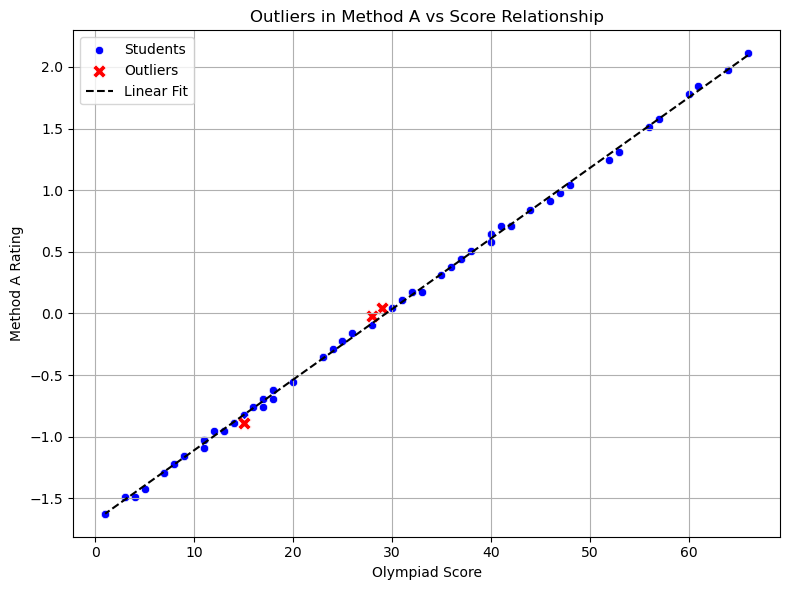

In [139]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pointSum', y='methodA', data=data, label='Students', color='blue')
sns.scatterplot(x='pointSum', y='methodA', data=outliers, label='Outliers', color='red', s=100, marker='X')
plt.plot(data['pointSum'], predicted, color='black', linestyle='--', label='Linear Fit')
plt.title("Outliers in Method A vs Score Relationship")
plt.xlabel("Olympiad Score")
plt.ylabel("Method A Rating")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Show how and where Method A differs in a principled way

## Rank Difference Histogram

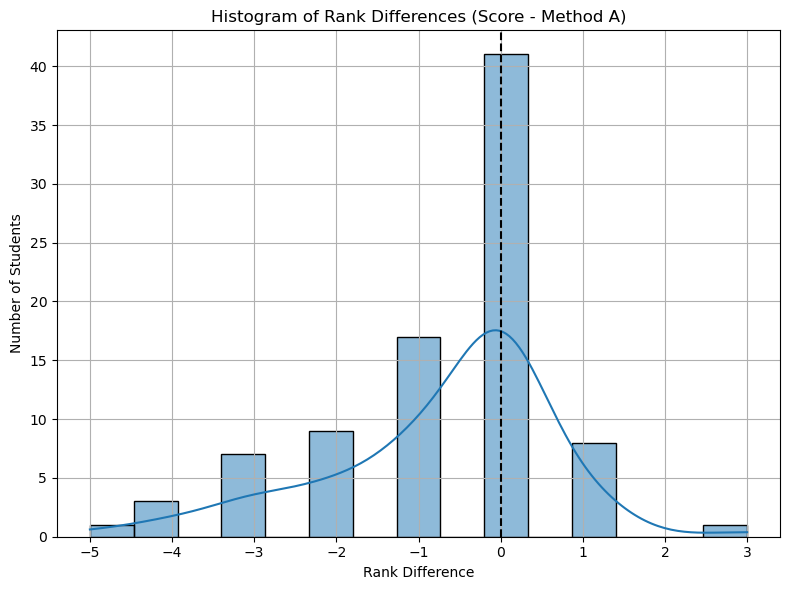

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(data['rank_diff'], bins=15, kde=True)
plt.title("Histogram of Rank Differences (Score - Method A)")
plt.xlabel("Rank Difference")
plt.ylabel("Number of Students")
plt.axvline(0, color='black', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()


## 2. Who Was Promoted or Demoted?

In [153]:
# Add helper columns
data['promotion'] = data['rank_diff'] > 0
data['demotion'] = data['rank_diff'] < 0

# Top 10 promoted
top_promoted = data.sort_values('rank_diff', ascending=False).head(10)
print("Top 10 Students Promoted by Method A:")
print(top_promoted[['name', 'pointSum', 'methodA', 'rank_score', 'rank_methodA', 'rank_diff']])

# Top 10 demoted
top_demoted = data.sort_values('rank_diff').head(10)
print("\nTop 10 Students Demoted by Method A:")
print(top_demoted[['name', 'pointSum', 'methodA', 'rank_score', 'rank_methodA', 'rank_diff']])


Top 10 Students Promoted by Method A:
                     name  pointSum   methodA  rank_score  rank_methodA  \
16     Одинцова Анастасия        41  0.709804          17            14   
34      Амангельдин Айбын        29  0.043137          35            34   
57         Лифенко Максим        14 -0.890196          58            57   
50       Тендиков Жанарыс        17 -0.690196          50            49   
51      Баймағамбет Арман        17 -0.690196          50            49   
52   Ауданбекұлы Ерболсын        16 -0.756863          53            52   
82      Устинов Александр         3 -1.490196          83            82   
83        Тұрсынбай Ақнұр         3 -1.490196          83            82   
28          Абдуллаев Аят        32  0.176471          29            28   
41      Полатхан Нұрболат        24 -0.290196          42            42   

    rank_diff  
16          3  
34          1  
57          1  
50          1  
51          1  
52          1  
82          1  
83      

/var/folders/sb/sxkvd5tn15q3xqx4tbdh5m780000gn/T/ipykernel_27251/1813259383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='name', y='rank_diff', data=pd.concat([top_promoted, top_demoted]), palette='coolwarm')


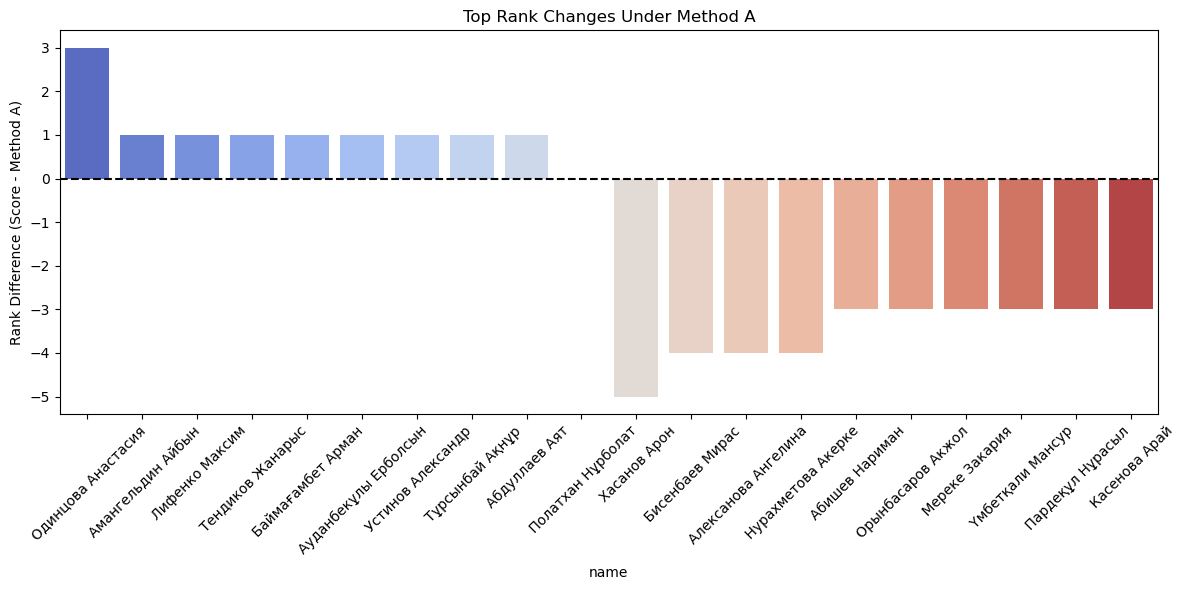

In [155]:
# Barplot of biggest rank changes
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='rank_diff', data=pd.concat([top_promoted, top_demoted]), palette='coolwarm')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--')
plt.title("Top Rank Changes Under Method A")
plt.ylabel("Rank Difference (Score - Method A)")
plt.tight_layout()
plt.show()


## 3. Rank Difference vs Score: Does Method A correct high/low scores?

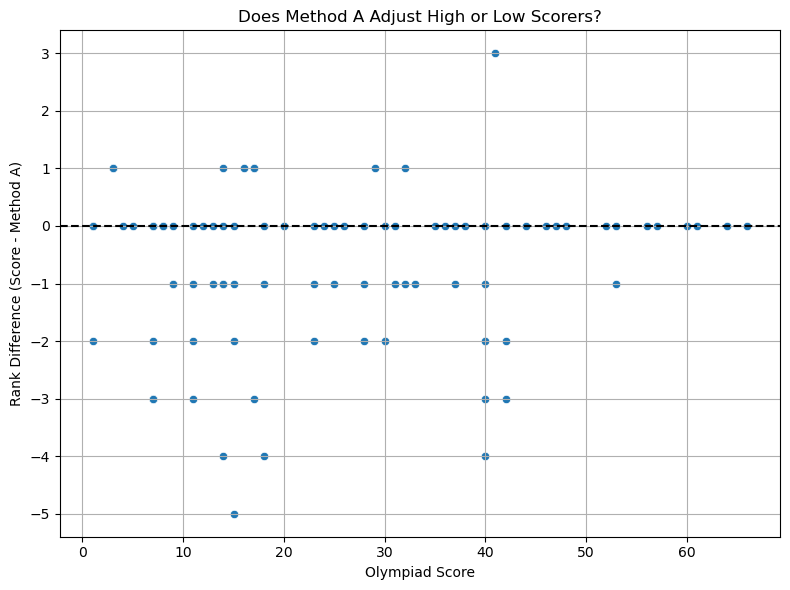

In [158]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pointSum', y='rank_diff', data=data)
plt.axhline(0, color='black', linestyle='--')
plt.title("Does Method A Adjust High or Low Scorers?")
plt.xlabel("Olympiad Score")
plt.ylabel("Rank Difference (Score - Method A)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 4.Inter-Rank Zone Violation

In [161]:
top10_raw = set(data.sort_values('rank_score').head(10)['name'])
top10_methodA = set(data.sort_values('rank_methodA').head(10)['name'])

in_both = top10_raw & top10_methodA
only_raw = top10_raw - in_both
only_methodA = top10_methodA - in_both

print("🔁 Students in Top 10 in Both:")
print(list(in_both))

print("\n⬆ Promoted into Top 10 by Method A:")
print(list(only_methodA))

print("\n⬇ Dropped Out of Top 10 by Method A:")
print(list(only_raw))


🔁 Students in Top 10 in Both:
[' Мурат Тимур', ' Юркевич Мирон', ' Таңсықбай Абзал', ' Нәрік Арсен', ' Сахипов Амир', ' Маратұлы Әлинұр', ' Роговский Владимир', ' Аманжолов Амирлан', ' Шарел Марғұлан', ' Даутов Жан']

⬆ Promoted into Top 10 by Method A:
[]

⬇ Dropped Out of Top 10 by Method A:
[]
